## FIRST Linear Regression 

### 1. Вводим необходимые библиотеки и создаем набор данных

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

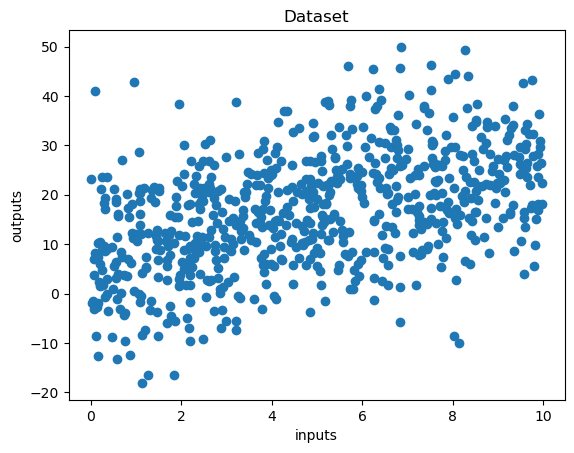

In [2]:
X = 10 * np.random.rand(700, 1)
y = 7 + 2 * X + 10 * np.random.randn(700, 1)

plt.scatter(X, y)
plt.title("Dataset")
plt.xlabel("inputs")
plt.ylabel("outputs")
plt.show()

#### 1.1 Разделяем данные на тренировочные и тестовые

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(525, 1) (525, 1) (175, 1) (175, 1)


### 2. Определяем класс Линейная регрессия и два метода: аналитический и градиентный спуск

In [12]:
class LinRegres:
    def init(model):
        pass

    def traingraddescent(model, X, y, rate_iter = 0.01, count_iter = 700):
        model.weights, model.bias = (np.zeros(X.shape[1])), 0
        costs = []
        
        for i in range(count_iter):
            costs.append(model.funcloss(X, y))
            if i % 100 == 0: 
                print(f"Cost at iteration {i}: {costs[-1]}")
                
            dJ_dw = (2/X.shape[0]) * np.dot(X.T, model.predict(X) - y)
            dJ_db = (2/X.shape[0]) * np.sum(model.predict(X) - y)
            model.weights = model.weights - rate_iter * dJ_dw
            model.bias = model.bias - rate_iter * dJ_db
            
        return model.weights, model.bias, costs

    def analytparam (model, X, y):
        X = np.hstack((X,np.ones([X.shape[0],1])))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
        model.bias = np.array(model.weights[-1])
        model.weights = np.array(model.weights[0:-1])
        return model.weights, model.bias

    def predict(model, X):
        return np.vstack(np.dot(X, model.weights) + model.bias)

    def funcloss(model, X, y):
        return (np.sum((model.predict(X) - y)**2))/(X.shape[0])

### 3. Обучаем модель аналитическим методом

In [5]:
line = LinRegres()
param = line.analytparam(X_train, y_train)
param

(array([[1.9106818]]), array([7.46152159]))

#### 3.1 Значения функции потерь на тренировочном и тестовом наборах

In [6]:
line.funcloss(X_train, y_train), line.funcloss(X_test, y_test)

(np.float64(111.76448909278656), np.float64(93.63094170877153))

#### 3.2 Визуализация построенной модели на наборе данных

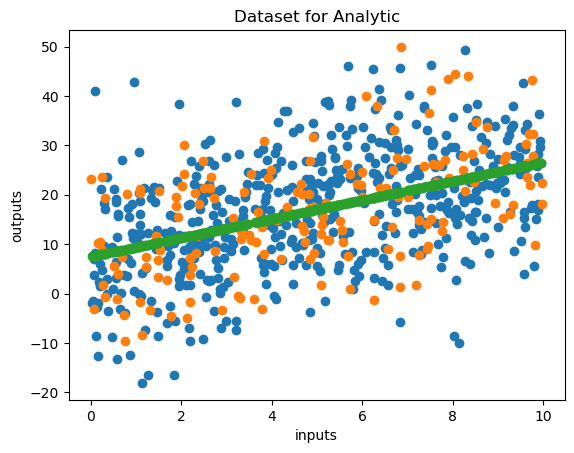

In [7]:
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.scatter(X_train, line.predict(X_train))
plt.title("Dataset for Analytic")
plt.xlabel("inputs")
plt.ylabel("outputs")
plt.show()

### 4. Обучаем модель методом Градиентного спуска

Cost at iteration 0: 420.53952344084485
Cost at iteration 100: 116.36279867168068
Cost at iteration 200: 113.47285330480993
Cost at iteration 300: 112.39918065298902
Cost at iteration 400: 112.00028973398304
Cost at iteration 500: 111.85209375917117
Cost at iteration 600: 111.79703598296217


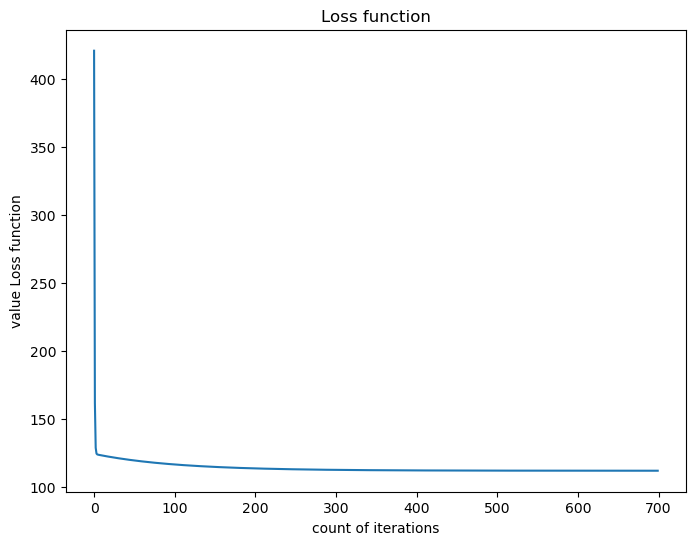

In [8]:
linegrad = LinRegres()
param, bias, costs = linegrad.traingraddescent(X_train, y_train, 0.01, 700)

fig = plt.figure(figsize=(8,6))
plt.plot(np.arange(700), costs)
plt.title("Loss function")
plt.xlabel("count of iterations")
plt.ylabel("value Loss function")
plt.show()

#### 4.1 Значения функции потерь на тренировочном и тестовом наборах

In [9]:
param, bias

(array([[1.94464623]]), np.float64(7.242853440275402))

In [10]:
linegrad.funcloss(X_train, y_train), linegrad.funcloss(X_test, y_test)

(np.float64(111.776580915104), np.float64(93.50155497275871))

#### 4.2 Визуализация построенной модели на наборе данных

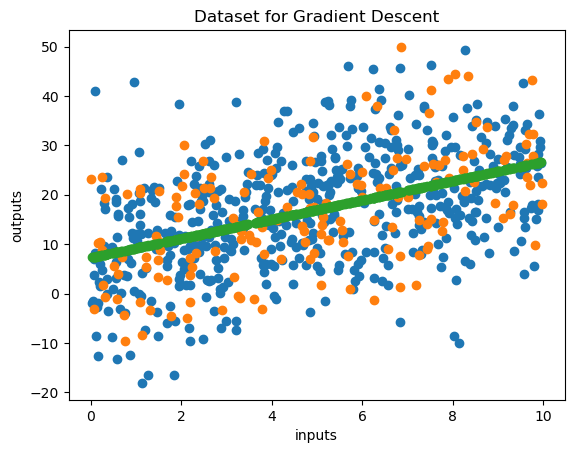

In [11]:
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.scatter(X_train, linegrad.predict(X_train))
plt.title("Dataset for Gradient Descent")
plt.xlabel("inputs")
plt.ylabel("outputs")
plt.show()